In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Update e instalação dos pacotes e dependências usados

#!/bin/bash

!sudo apt-get update
!sudo apt-get install -y python3-pip

!pip3 install torch transformers datasets accelerate seqeval
!pip install evaluate seqeval
!pip install -q evaluate seqeval accelerate

!echo "Environment setup complete!"

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,378 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-

In [ ]:
# Importações necessárias

import pandas as pd
import csv
import re
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, EarlyStoppingCallback)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import evaluate
metric = evaluate.load("seqeval")

In [ ]:
# Definição dos rótulos BIO
lista_rotulos = ["O", "B-WRONG", "I-WRONG"]
label_to_id = {label: i for i, label in enumerate(lista_rotulos)}
id_to_label = {i: label for i, label in enumerate(lista_rotulos)}

In [ ]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Remove os índices de ignorados (-100) e converte para labels de texto
    true_predictions = [
        [id_to_label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id_to_label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
# Verifica se a GPU está disponível

if torch.cuda.is_available():
    print("GPU is available!")
else:
    print("Please switch to a GPU-enabled environment.")

GPU is available!


In [ ]:
# Lê o início do arquivo TSV

df = pd.read_csv('/content/drive/MyDrive/IFES/IC/get-pt/train_bio.tsv', sep='\t', encoding='latin-1', quoting=csv.QUOTE_NONE)
print(df.head())

          SentenÃ§a Original NÂ°1
O                               O
maior                           O
mal                             O
da                              O
sociedade                       O


In [ ]:
# Lê arquivo CONLL (TSV)

def ler_conll(
    path: str,
    *,
    ignore_header_regex: str = r"^\s*Sentença\s+Original\s+N[°º]\s*\d+",
    allow_space_in_token: bool = False,
    strict_two_columns: bool = False,
    verbose: bool = True,
) -> Tuple[List[List[str]], List[List[str]]]:
    header_pat = re.compile(ignore_header_regex, flags=re.IGNORECASE)
    tokens_per_sent, tags_per_sent = [], []
    cur_tokens, cur_tags = [], []

    def flush_sentence():
        nonlocal cur_tokens, cur_tags
        if cur_tokens:
            tokens_per_sent.append(cur_tokens)
            tags_per_sent.append(cur_tags)
        cur_tokens, cur_tags = [], []

    with open(path, "r", encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.rstrip("\n")

            # Ignora linhas de cabeçalho por sentença
            if header_pat.search(line):
                flush_sentence()
                continue

            # Delimitador de sentença
            if line.strip() == "":
                flush_sentence()
                continue

            # Tenta split por TAB primeiro, senão por espaço
            if "\t" in line:
                parts = line.split("\t")
            else:
                # Divide por qualquer espaço
                parts = line.strip().split()

            if strict_two_columns:
                if len(parts) != 2:
                    if verbose:
                        print(f"[AVISO] Linha {lineno} ignorada (esperado 2 colunas): {line}")
                    continue
                token, tag = parts[0], parts[1]
            else:
                if len(parts) < 2:
                    if verbose:
                        print(f"[AVISO] Linha {lineno} ignorada (colunas insuficientes): {line}")
                    continue
                if allow_space_in_token:
                    # Última coluna é tag; o resto é token (pode conter espaços/tabs)
                    *token_parts, tag = parts
                    token = " ".join(token_parts)
                else:
                    # Primeira é token, última é tag (se houver colunas no meio, descartamos/avisamos)
                    token, tag = parts[0], parts[-1]
                    if len(parts) > 2 and verbose:
                        print(f"[OBSERVAÇÃO] Linha {lineno} possuía colunas extras; usando 1ª como token e última como tag.")

            # Sanidade básica da tag
            if not tag or tag.isspace():
                if verbose:
                    print(f"[AVISO] Linha {lineno} com tag vazia; ignorada: {line}")
                continue

            cur_tokens.append(token)
            cur_tags.append(tag)

    # Última sentença (se não terminar com linha em branco)
    flush_sentence()

    return tokens_per_sent, tags_per_sent

In [ ]:
# Mapeia Label2ID e ID2Label

def build_label_maps(tags_per_sent: List[List[str]]) -> Tuple[Dict[str, int], Dict[int, str]]:
    labels = set()
    for sent_tags in tags_per_sent:
        labels.update(sent_tags)

    labels = list(labels)

    if "O" in labels:
        labels.remove("O")
        labels = ["O"] + sorted(labels)
    else:
        labels = sorted(labels)

    label2id = {lab: i for i, lab in enumerate(labels)} # Converte texto em número ['O': 0, 'B-WRONG': 1, 'I-WRONG': 2]
    id2label = {i: lab for lab, i in label2id.items()} # Converte número em texto [0: 'O', 1: 'B-WRONG', 2: 'I-WRONG']
    return label2id, id2label

In [ ]:
# Constrói um dataset Hugging Face com colunas de tokens (List[str]) e ner_tags (List[int]).

def make_hf_dataset_from_tokens(
    tokens_per_sent: List[List[str]],
    tags_per_sent: List[List[str]],
    label2id: Optional[Dict[str, int]] = None,
) -> Tuple[Dataset, Dict[str, int]]:

    # Verifica se as sentenças de tokens e as sentenças de tags são equivalentes (mesmo número)
    assert len(tokens_per_sent) == len(tags_per_sent), "tokens e tags desalinhados"

    # Associa Label2ID ao mapeamento das tags feito anteriormente
    if label2id is None:
        label2id, _ = build_label_maps(tags_per_sent)

    # Tags desconhecidas serão associadas à tag O
    O_ID = label2id.get("O", 0)

    # Mapeamento com tratamento de erro
    encoded_tags = []
    for tags in tags_per_sent:
        sentence_tags = []
        for tag in tags:
            sentence_tags.append(label2id.get(tag, O_ID)) # Verifica se tag está mapeada ou se uso o ID 0
        encoded_tags.append(sentence_tags)

    ds = Dataset.from_dict({"tokens": tokens_per_sent, "ner_tags": encoded_tags})
    return ds, label2id

In [ ]:
# Função para equiparar lista de labels com lista de tokens

def tokenize_and_align_labels(batch, tokenizer, label_all_subtokens: bool = False):
    tokenized = tokenizer(
        batch["tokens"],
        truncation=True,
        padding=True,
        is_split_into_words=True,
    )

    all_labels = []
    for i, word_labels in enumerate(batch["ner_tags"]):
        # Mapeia o subtoken com a palavra original
        word_ids = tokenized.word_ids(batch_index=i)
        previous_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                # Caractere especial é ignorado
                label_ids.append(-100)
            elif word_id != previous_word_id:
                # Primeiro pedaço da palavra recebe tag original
                label_ids.append(word_labels[word_id])
            else:
                # Sub-token da mesma palavra (word) é alinhado à label original
                label_ids.append(word_labels[word_id] if label_all_subtokens else -100)
            previous_word_id = word_id

        all_labels.append(label_ids)

    tokenized["labels"] = all_labels
    return tokenized


In [ ]:
# Função que retorna o objeto DatasetDict para o treinamento do modelo a partir das funções anteriores.

def load_custom_conll_dataset(
    files: Dict[str, str] | str,
    *,
    fixed_label2id: Optional[Dict[str, int]] = None,
    allow_space_in_token: bool = False,
    strict_two_columns: bool = False,
    verbose: bool = True,
) -> Tuple[DatasetDict, Dict[str, int], Dict[int, str]]:

    if isinstance(files, str):
        files = {"train": files}

    datasets_splits = {}
    cache_tokens = {}
    cache_tags = {}

    # Lê os splits
    for split_name, path in files.items():
        tokens_per_sent, tags_per_sent = ler_conll(
            path,
            allow_space_in_token=allow_space_in_token,
            strict_two_columns=strict_two_columns,
            verbose=verbose,
        )
        cache_tokens[split_name] = tokens_per_sent
        cache_tags[split_name] = tags_per_sent

    # Determinar o mapeamento de labels
    if fixed_label2id is not None:
        # Mapeamento fixo (BIO)
        accumulated_label2id = fixed_label2id
    else:
        # Remapeaia todas as tags caso não tenha labels definidas (fallback)
        all_tags = []
        for split_name in files.keys():
            all_tags.extend(cache_tags[split_name])
        accumulated_label2id, _ = build_label_maps(all_tags)

    accumulated_id2label = {i: lab for lab, i in accumulated_label2id.items()}

    # Constrói datasets usando o mapeamento (BIO)
    for split_name in files.keys():
        ds, _ = make_hf_dataset_from_tokens(
            cache_tokens[split_name],
            cache_tags[split_name],
            label2id=accumulated_label2id,
        )
        datasets_splits[split_name] = ds

    dset = DatasetDict(datasets_splits)
    return dset, accumulated_label2id, accumulated_id2label

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carregamento do Dataset já com os labels BIO
path_treino = "/content/drive/MyDrive/IFES/IC/get-pt/train_bio.tsv"
path_teste = "/content/drive/MyDrive/IFES/IC/get-pt/test_bio.tsv"
path_validacao = "/content/drive/MyDrive/IFES/IC/get-pt/val_bio.tsv"

dataset, _, _ = load_custom_conll_dataset(
      files={"train": path_treino, "test": path_teste, "validation": path_validacao},
      fixed_label2id=label_to_id,
      allow_space_in_token=False,
      strict_two_columns=False,
      verbose=True,
)

print(dataset)
print("labels:", label_to_id)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 13860
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 3850
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 1540
    })
})
labels: {'O': 0, 'B-WRONG': 1, 'I-WRONG': 2}


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("neuralmind/bert-base-portuguese-cased")

# Tokenização + alinhamento das labels
tokenized_dataset = dataset.map(
    lambda batch: tokenize_and_align_labels(batch, tokenizer, label_all_subtokens=False), # Aplica a função para alinhamento de tokens e tags
    batched=True # Processa várias sentenças simultaneamente
)

# Carregamento do Modelo
model = AutoModelForTokenClassification.from_pretrained(
    "neuralmind/bert-base-portuguese-cased",
    num_labels=len(lista_rotulos),
    id2label=id_to_label,
    label2id=label_to_id
)

model.to(device)

print(f"\nModelo movido para: {device}")
print(f"\nOs rótulos foram definidos como: \n{model.config.id2label}")

Map:   0%|          | 0/13860 [00:00<?, ? examples/s]

Map:   0%|          | 0/3850 [00:00<?, ? examples/s]

Map:   0%|          | 0/1540 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


Modelo movido para: cuda

Os rótulos foram definidos como: 
{0: 'O', 1: 'B-WRONG', 2: 'I-WRONG'}


In [ ]:
# Configurações de Treinamento

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",       # Estratégia de save igual à de eval
    save_steps=100,
    load_best_model_at_end=True, # Salvamento e carregamento do melhor modelo ao final
    metric_for_best_model="f1",  # O critério é o F1-Score
    fp16=True,
    per_device_train_batch_size=32,
    learning_rate=2e-5,
    num_train_epochs=10,         # 3 épocas
    weight_decay=0.01,
    logging_dir="./logs",
    report_to=[],
)

In [ ]:
# Cria o data collator que faz padding dinâmico
data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True,
)

In [ ]:
# Treinamento do modelo

from transformers import logging
logging.set_verbosity_error()

model = AutoModelForTokenClassification.from_pretrained(
    "neuralmind/bert-base-portuguese-cased",
    num_labels=len(lista_rotulos),
    id2label=id_to_label,
    label2id=label_to_id
)

# 2. Argumentos de Treinamento
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch", # Avalia a cada época para monitorar os spans
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    fp16=torch.cuda.is_available(), # Acelera se houver GPU
)

# 3. Inicialização do Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# 4. Iniciar o treinamento
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.644', 'grad_norm': '1.107', 'learning_rate': '1.993e-05', 'epoch': '0.01153'}
{'loss': '0.393', 'grad_norm': '0.5308', 'learning_rate': '1.985e-05', 'epoch': '0.02307'}
{'loss': '0.229', 'grad_norm': '0.999', 'learning_rate': '1.978e-05', 'epoch': '0.0346'}
{'loss': '0.4013', 'grad_norm': '1.268', 'learning_rate': '1.97e-05', 'epoch': '0.04614'}
{'loss': '0.3045', 'grad_norm': '3.323', 'learning_rate': '1.962e-05', 'epoch': '0.05767'}
{'loss': '0.2151', 'grad_norm': '1.333', 'learning_rate': '1.955e-05', 'epoch': '0.0692'}
{'loss': '0.3423', 'grad_norm': '0.9674', 'learning_rate': '1.947e-05', 'epoch': '0.08074'}
{'loss': '0.3105', 'grad_norm': '0.9336', 'learning_rate': '1.939e-05', 'epoch': '0.09227'}
{'loss': '0.3406', 'grad_norm': '0.7964', 'learning_rate': '1.932e-05', 'epoch': '0.1038'}
{'loss': '0.2548', 'grad_norm': '0.6585', 'learning_rate': '1.924e-05', 'epoch': '0.1153'}
{'loss': '0.3359', 'grad_norm': '0.908', 'learning_rate': '1.916e-05', 'epoch': '0.1269'}
{'l

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1712', 'grad_norm': '1.252', 'learning_rate': '1.609e-05', 'epoch': '0.5882'}
{'loss': '0.2491', 'grad_norm': '1.154', 'learning_rate': '1.601e-05', 'epoch': '0.5998'}
{'loss': '0.2237', 'grad_norm': '1.505', 'learning_rate': '1.593e-05', 'epoch': '0.6113'}
{'loss': '0.1244', 'grad_norm': '0.8363', 'learning_rate': '1.586e-05', 'epoch': '0.6228'}
{'loss': '0.2911', 'grad_norm': '2.411', 'learning_rate': '1.578e-05', 'epoch': '0.6344'}
{'loss': '0.1736', 'grad_norm': '1.236', 'learning_rate': '1.57e-05', 'epoch': '0.6459'}
{'loss': '0.2248', 'grad_norm': '1.348', 'learning_rate': '1.562e-05', 'epoch': '0.6574'}
{'loss': '0.2182', 'grad_norm': '3.091', 'learning_rate': '1.555e-05', 'epoch': '0.669'}
{'loss': '0.1943', 'grad_norm': '1.214', 'learning_rate': '1.547e-05', 'epoch': '0.6805'}
{'loss': '0.2003', 'grad_norm': '1.409', 'learning_rate': '1.539e-05', 'epoch': '0.692'}
{'loss': '0.2011', 'grad_norm': '1.083', 'learning_rate': '1.532e-05', 'epoch': '0.7036'}
{'loss': '0.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1634', 'grad_norm': '2.873', 'learning_rate': '7.074e-07', 'epoch': '2.895'}
{'loss': '0.1091', 'grad_norm': '1.257', 'learning_rate': '6.305e-07', 'epoch': '2.907'}
{'loss': '0.1356', 'grad_norm': '4.178', 'learning_rate': '5.536e-07', 'epoch': '2.918'}
{'loss': '0.1429', 'grad_norm': '1.754', 'learning_rate': '4.767e-07', 'epoch': '2.93'}
{'loss': '0.09091', 'grad_norm': '2.986', 'learning_rate': '3.998e-07', 'epoch': '2.941'}
{'loss': '0.1243', 'grad_norm': '2.098', 'learning_rate': '3.23e-07', 'epoch': '2.953'}
{'loss': '0.1167', 'grad_norm': '1.537', 'learning_rate': '2.461e-07', 'epoch': '2.964'}
{'loss': '0.1264', 'grad_norm': '2.895', 'learning_rate': '1.692e-07', 'epoch': '2.976'}
{'loss': '0.09617', 'grad_norm': '1.504', 'learning_rate': '9.227e-08', 'epoch': '2.987'}
{'loss': '0.1255', 'grad_norm': '2.861', 'learning_rate': '1.538e-08', 'epoch': '2.999'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.2104', 'eval_precision': '0.6774', 'eval_recall': '0.6095', 'eval_f1': '0.6416', 'eval_accuracy': '0.9456', 'eval_runtime': '12.53', 'eval_samples_per_second': '307.3', 'eval_steps_per_second': '38.47', 'epoch': '3'}
{'train_runtime': '689.3', 'train_samples_per_second': '60.32', 'train_steps_per_second': '3.773', 'train_loss': '0.1823', 'epoch': '3'}


TrainOutput(global_step=2601, training_loss=0.1822517600608005, metrics={'train_runtime': 689.3243, 'train_samples_per_second': 60.32, 'train_steps_per_second': 3.773, 'train_loss': 0.1822517600608005, 'epoch': 3.0})

A calcular predições para: Matriz de Confusão - Conjunto de Treino (Sanidade)...


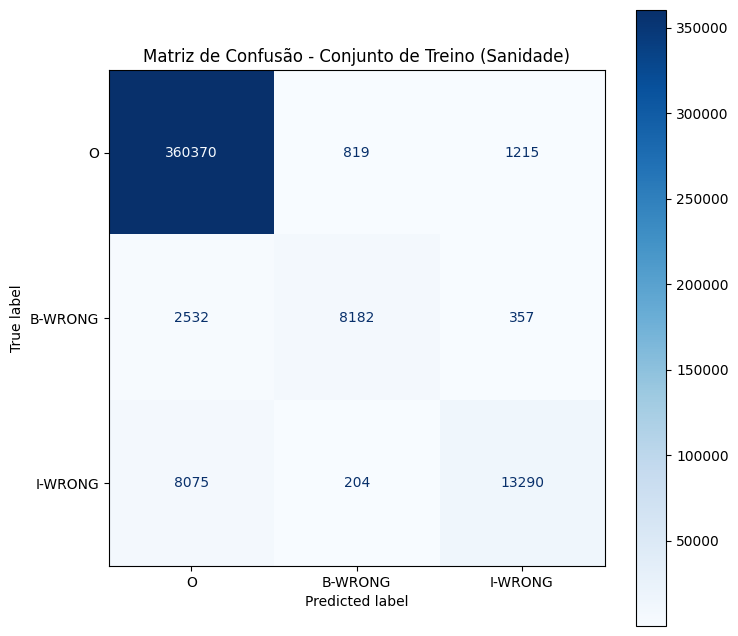

A calcular predições para: Matriz de Confusão - Conjunto de Teste Final...


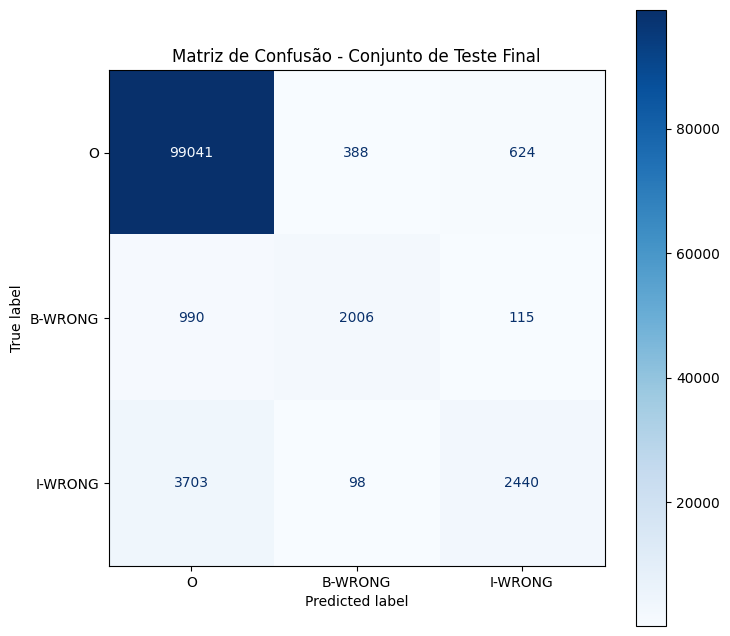

A calcular predições para: Matriz de Confusão - Conjunto de Teste (Avaliação Real)...


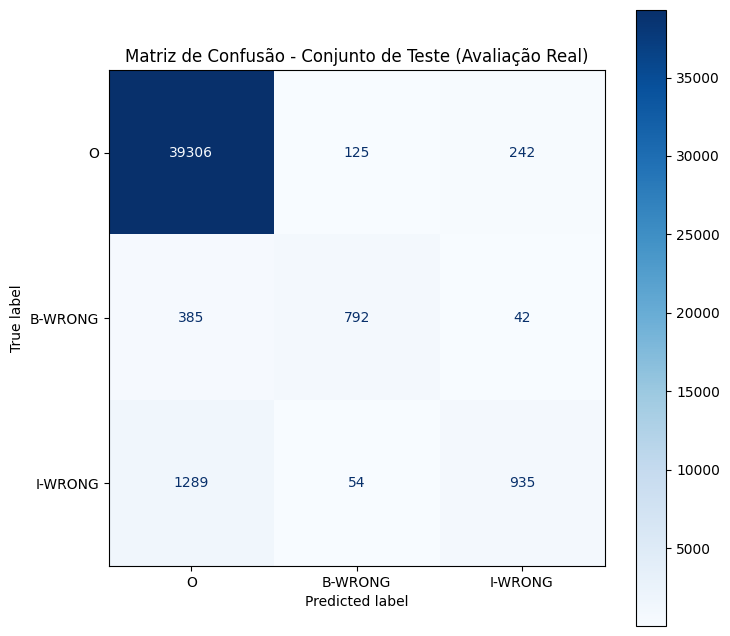

In [ ]:
# Matriz de Confusão (Teste de Sanidade)
def plot_confusion_matrix(dataset_split, title):
    print(f"A calcular predições para: {title}...")
    predictions, labels, _ = trainer.predict(tokenized_dataset[dataset_split])
    predictions = np.argmax(predictions, axis=2)

    # Filtra IDs -100
    y_pred = [id_to_label[p] for prediction, label in zip(predictions, labels)
              for (p, l) in zip(prediction, label) if l != -100]
    y_true = [id_to_label[l] for prediction, label in zip(predictions, labels)
              for (p, l) in zip(prediction, label) if l != -100]

    cm = confusion_matrix(y_true, y_pred, labels=lista_rotulos)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lista_rotulos)
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()

# Execução das Matrizes de Confusão
plot_confusion_matrix("train", "Matriz de Confusão - Conjunto de Treino (Sanidade)")
plot_confusion_matrix("test", "Matriz de Confusão - Conjunto de Teste Final")
plot_confusion_matrix("validation", "Matriz de Confusão - Conjunto de Teste (Avaliação Real)")

In [ ]:
# Reportar Métricas

# Avaliação no conjunto de treino para obter as métricas finais
print("\n*** MÉTRICAS FINAIS (TESTE) ***")
metrics_teste = trainer.evaluate(tokenized_dataset["test"])

print(f"Precisão: {metrics_teste.get('eval_precision', 'N/A'):.4f}")
print(f"Revocação: {metrics_teste.get('eval_recall', 'N/A'):.4f}")
print(f"F1-Score: {metrics_teste.get('eval_f1', 'N/A'):.4f}")
print(f"Acurácia: {metrics_teste.get('eval_accuracy', 'N/A'):.4f}")


*** MÉTRICAS FINAIS (TESTE) ***
{'eval_loss': '0.2094', 'eval_precision': '0.6884', 'eval_recall': '0.6136', 'eval_f1': '0.6489', 'eval_accuracy': '0.9459', 'eval_runtime': '11.69', 'eval_samples_per_second': '329.3', 'eval_steps_per_second': '41.22', 'epoch': '3'}
Precisão: 0.6884
Revocação: 0.6136
F1-Score: 0.6489
Acurácia: 0.9459


In [ ]:
# Salvamento do Modelo
trainer.save_model("./ner_model")
tokenizer.save_pretrained("./ner_model")
print("\nModelo e Tokenizador salvos em: ./ner_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo e Tokenizador salvos em: ./ner_model
